In [1]:
import pandas as pd

# Load the CSV
data = pd.read_csv('/home/user/abd_ws/src/tests/tests/gps_data.csv')

# Display the first few rows
print(data.head())

# Basic statistics
print(data.describe())


             Timestamp  Latitude  Longitude    Altitude
0  2024-12-22 16:24:20  43.65319 -79.383287  100.539397
1  2024-12-22 16:24:22  43.65319 -79.383287  100.539394
2  2024-12-22 16:24:23  43.65319 -79.383287  100.539392
3  2024-12-22 16:24:24  43.65319 -79.383287  100.539390
4  2024-12-22 16:24:25  43.65319 -79.383287  100.539388
         Latitude   Longitude    Altitude
count  117.000000  117.000000  117.000000
mean    43.653166  -79.383249  100.539730
std      0.000033    0.000039    0.000176
min     43.653118  -79.383294  100.539362
25%     43.653130  -79.383287  100.539616
50%     43.653179  -79.383255  100.539745
75%     43.653198  -79.383206  100.539851
max     43.653207  -79.383199  100.540125


In [3]:
from shapely.geometry import Polygon

# Example: Create a polygon from GPS data
coordinates = list(zip(data['Longitude'], data['Latitude']))
perimeter = Polygon(coordinates)

# Print the area and bounds
print(f"Perimeter Area: {perimeter.area}")
print(f"Perimeter Bounds: {perimeter.bounds}")


Perimeter Area: 6.8150289689116156e-09
Perimeter Bounds: (-79.38329390987892, 43.65311841725299, -79.38319935034441, 43.65320659474696)


Polygon plot saved to /home/user/abd_ws/src/tests/tests/gps_polygon.png


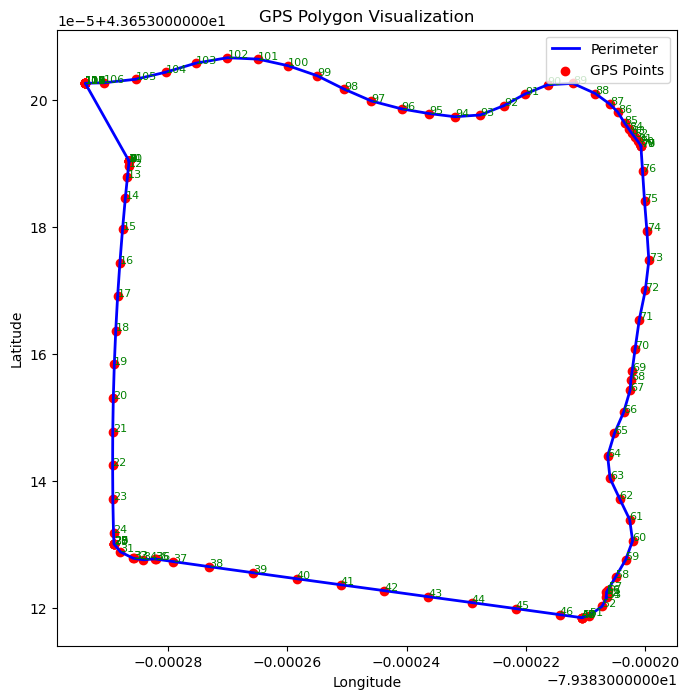

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
from shapely.geometry.polygon import LinearRing

# Load the GPS data
file_path = '/home/user/abd_ws/src/tests/tests/gps_data.csv'  # Path to your GPS data file
data = pd.read_csv(file_path)

# Extract latitude and longitude
latitudes = data['Latitude']
longitudes = data['Longitude']

# Create a list of (longitude, latitude) tuples
coordinates = list(zip(longitudes, latitudes))

# Create a Shapely polygon
polygon = Polygon(coordinates)

# Plot the polygon
fig, ax = plt.subplots(figsize=(8, 8))
x, y = polygon.exterior.xy  # Get the x and y coordinates of the polygon exterior
ax.plot(x, y, color='blue', linewidth=2, label='Perimeter')

# Add individual GPS points
ax.scatter(longitudes, latitudes, color='red', marker='o', label='GPS Points')

# Add annotations (optional)
for i, coord in enumerate(coordinates):
    ax.text(coord[0], coord[1], f'{i+1}', fontsize=8, color='green')

# Set plot labels and title
ax.set_title('GPS Polygon Visualization')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()

# Save the plot as an image
output_path = '/home/user/abd_ws/src/tests/tests/gps_polygon.png'
plt.savefig(output_path)
print(f"Polygon plot saved to {output_path}")

# Show the plot
plt.show()


Polygon plot saved to /home/user/abd_ws/src/tests/tests/gps_polygon_connected.png


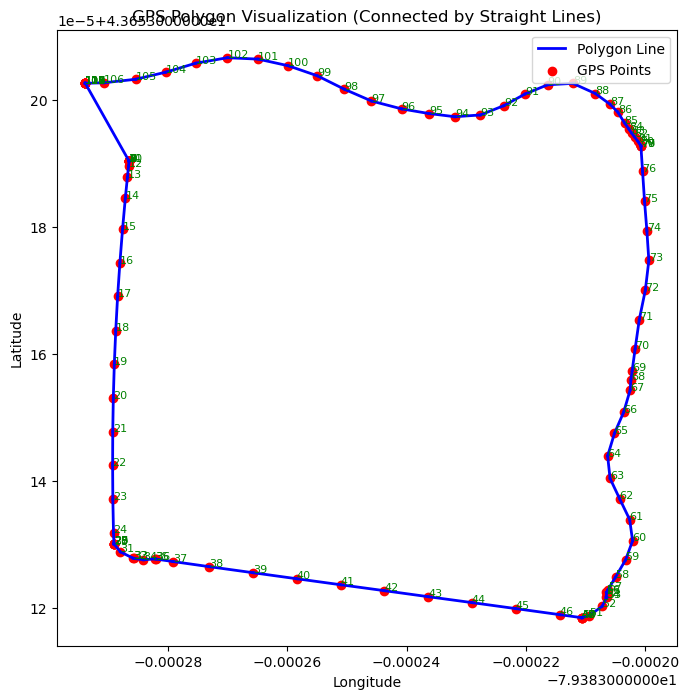

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# Load the GPS data
file_path = '/home/user/abd_ws/src/tests/tests/gps_data.csv'  # Path to your GPS data file
data = pd.read_csv(file_path)

# Extract latitude and longitude
latitudes = data['Latitude']
longitudes = data['Longitude']

# Create a list of (longitude, latitude) tuples
coordinates = list(zip(longitudes, latitudes))

# Ensure the polygon is closed by adding the first point at the end
if coordinates[0] != coordinates[-1]:
    coordinates.append(coordinates[0])

# Create a Shapely polygon (optional, just for geometric analysis)
polygon = Polygon(coordinates)

# Plot the polygon
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the polygon lines
for i in range(len(coordinates) - 1):
    x_coords = [coordinates[i][0], coordinates[i + 1][0]]
    y_coords = [coordinates[i][1], coordinates[i + 1][1]]
    ax.plot(x_coords, y_coords, color='blue', linewidth=2, label='Polygon Line' if i == 0 else "")

# Add individual GPS points
ax.scatter(longitudes, latitudes, color='red', marker='o', label='GPS Points')

# Add annotations (optional)
for i, coord in enumerate(coordinates[:-1]):  # Exclude the duplicate last point for labeling
    ax.text(coord[0], coord[1], f'{i+1}', fontsize=8, color='green')

# Set plot labels and title
ax.set_title('GPS Polygon Visualization (Connected by Straight Lines)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()

# Save the plot as an image
output_path = '/home/user/abd_ws/src/tests/tests/gps_polygon_connected.png'
plt.savefig(output_path)
print(f"Polygon plot saved to {output_path}")

# Show the plot
plt.show()


In [11]:
if not polygon.is_valid:
    raise ValueError("The polygon formed by the GPS coordinates is invalid.")

ValueError: The polygon formed by the GPS coordinates is invalid.

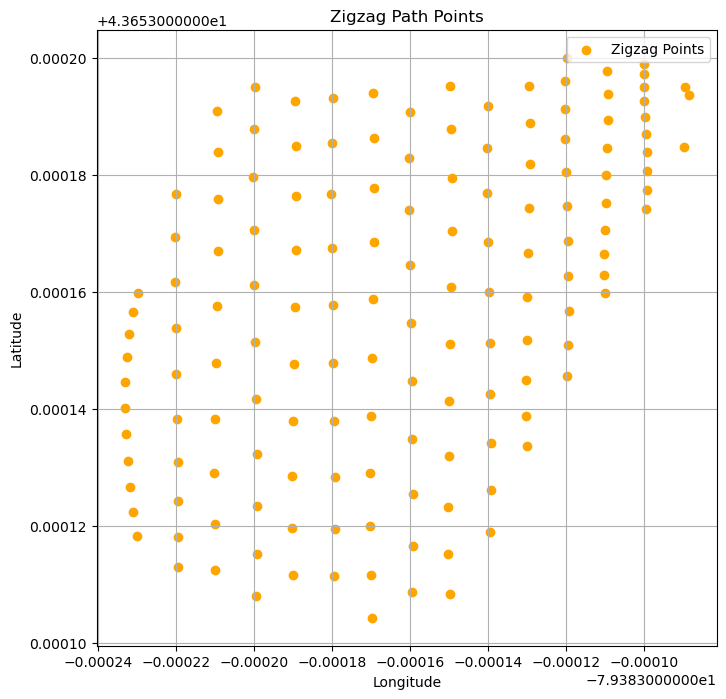

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# File path to the waypoints CSV
file_path = "/home/user/abd_ws/src/tests/tests/zigzag_path_waypoints.csv"  
zigzag_data = pd.read_csv(file_path)

# Extract longitude and latitude
longitudes = zigzag_data["longitude"]
latitudes = zigzag_data["latitude"]

# Plot the zigzag points
plt.figure(figsize=(8, 8))
plt.scatter(longitudes, latitudes, color='orange', marker='o', label="Zigzag Points")
plt.title("Zigzag Path Points")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


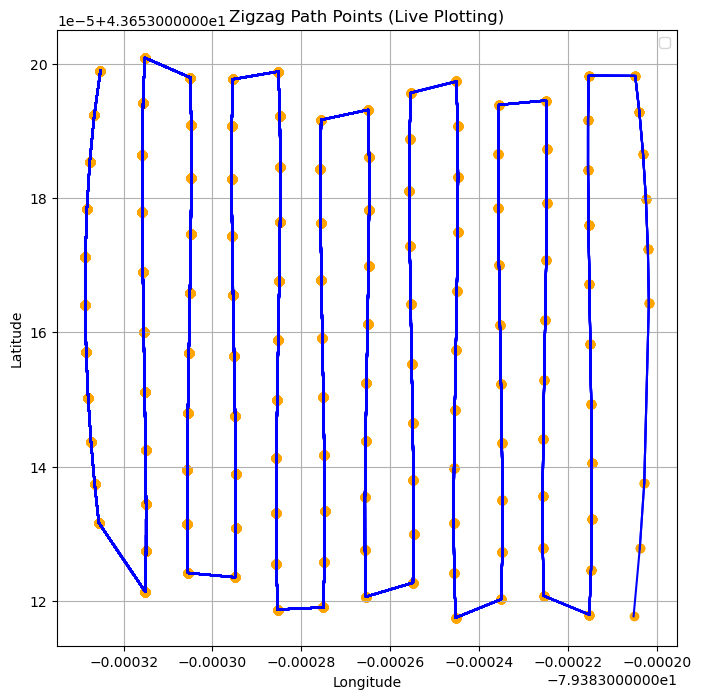

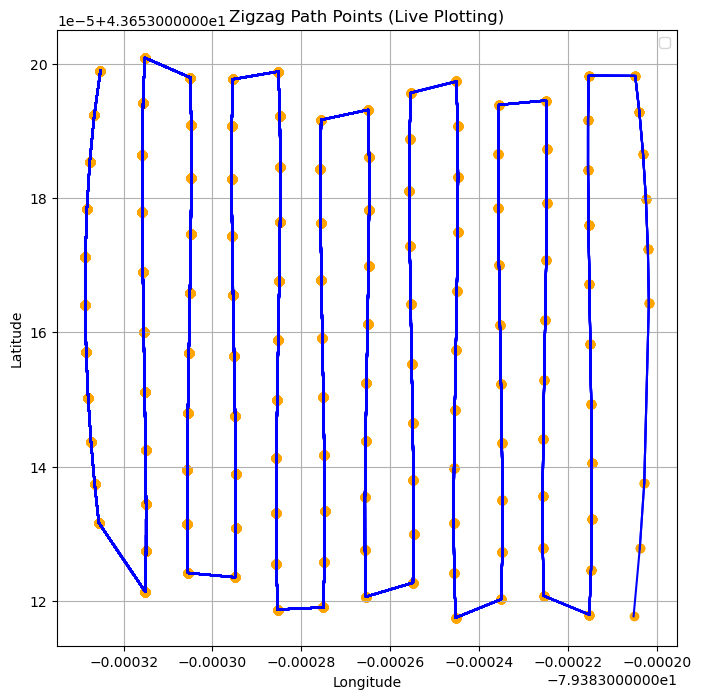

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# File path to the waypoints CSV
file_path = "/home/user/abd_ws/src/tests/tests/Zigzag_paths/secondary_zigzag_path_waypoints.csv"  
zigzag_data = pd.read_csv(file_path)

# Extract longitude and latitude and convert to NumPy arrays
longitudes = zigzag_data["longitude"].to_numpy()
latitudes = zigzag_data["latitude"].to_numpy()

# Set up the plot
plt.figure(figsize=(8, 8))
plt.title("Zigzag Path Points (Live Plotting)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

# Live plotting loop
for i in range(len(longitudes)):
    # Clear the current output
    clear_output(wait=True)
    
    # Plot the data up to the current point
    plt.scatter(longitudes[:i + 1], latitudes[:i + 1], color='orange', marker='o')
    plt.plot(longitudes[:i + 1], latitudes[:i + 1], color='blue')  # Connect the points with a line
    
    # Add legend and labels
    plt.legend()
    plt.grid(True)
    
    # Display the updated plot
    display(plt.gcf())
    
    # Pause to simulate live plotting
    time.sleep(0.5)  # Adjust the delay for speed

# Final display of the completed plot
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


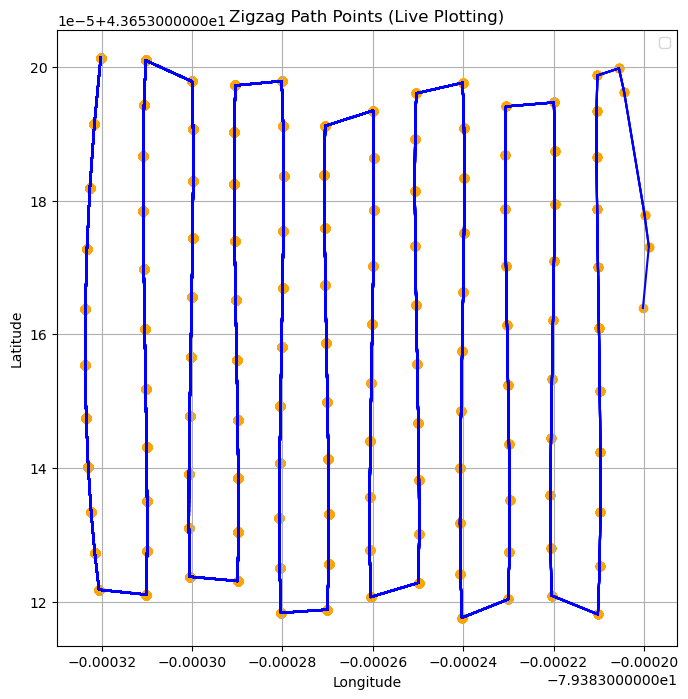

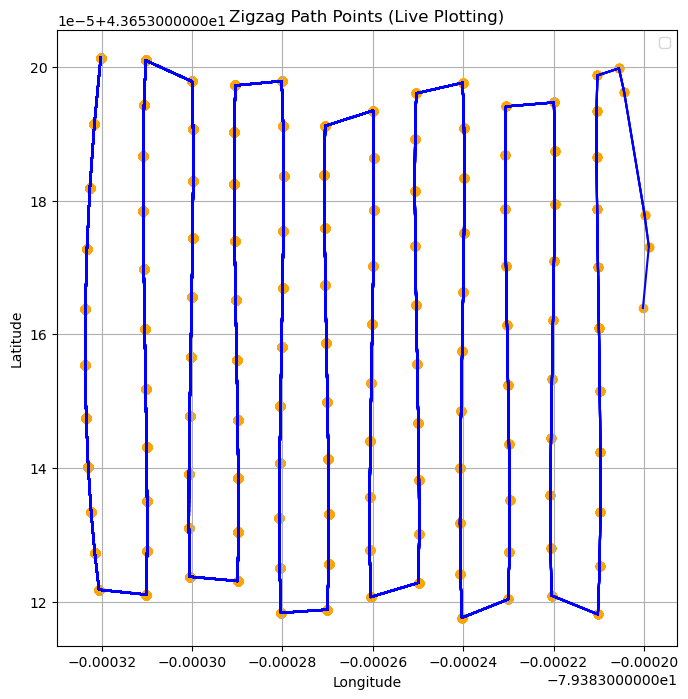

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# File path to the waypoints CSV
file_path = "/home/user/abd_ws/src/tests/tests/Zigzag_paths/primary_zigzag_path_waypoints.csv"  
zigzag_data = pd.read_csv(file_path)

# Extract longitude and latitude and convert to NumPy arrays
longitudes = zigzag_data["longitude"].to_numpy()
latitudes = zigzag_data["latitude"].to_numpy()

# Set up the plot
plt.figure(figsize=(8, 8))
plt.title("Zigzag Path Points (Live Plotting)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

# Live plotting loop
for i in range(len(longitudes)):
    # Clear the current output
    clear_output(wait=True)
    
    # Plot the data up to the current point
    plt.scatter(longitudes[:i + 1], latitudes[:i + 1], color='orange', marker='o')
    plt.plot(longitudes[:i + 1], latitudes[:i + 1], color='blue')  # Connect the points with a line
    
    # Add legend and labels
    plt.legend()
    plt.grid(True)
    
    # Display the updated plot
    display(plt.gcf())
    
    # Pause to simulate live plotting
    time.sleep(0.5)  # Adjust the delay for speed

# Final display of the completed plot
plt.show()


In [7]:
import csv


def load_and_concatenate_waypoints(self, primary_file, secondary_file):
        waypoints = []
        try:
            # Load primary waypoints
            with open(primary_file, 'r') as file:
                reader = csv.reader(file)
                for row_number, row in enumerate(reader, start=1):
                    try:
                        lat = float(row[1])
                        lon = float(row[0])
                        waypoints.insert(0, (lat, lon))  # Reverse order for primary file
                    except (ValueError, IndexError):
                        self.get_logger().warn(f"Skipping invalid row in {file1}, row {row_number}: {row}")

            # Load secondary waypoints
            with open(secondary_file, 'r') as file:
                reader = csv.reader(file)
                for row_number, row in enumerate(reader, start=1):
                    try:
                        lat = float(row[1])
                        lon = float(row[0])
                        waypoints.append((lat, lon))
                    except (ValueError, IndexError):
                        self.get_logger().warn(f"Skipping invalid row in {file2}, row {row_number}: {row}")
        except FileNotFoundError as e:
            self.get_logger().error(f"Waypoint file not found: {e}")
            exit()
        return waypoints[::-1]

In [8]:
# Replace 'primary.csv' and 'secondary.csv' with your actual file paths
file1 = '/home/user/abd_ws/src/tests/tests/Zigzag_paths/primary_zigzag_path_waypoints.csv'
file2 = '/home/user/abd_ws/src/tests/tests/Zigzag_paths/secondary_zigzag_path_waypoints.csv'

load_and_concatenate_waypoints(self, file1, file2)

NameError: name 'self' is not defined

In [25]:
import csv
import matplotlib.pyplot as plt

class WaypointProcessor:
    def __init__(self, logger=None):
        self.logger = logger

    def get_logger(self):
        return self.logger or self  # Use a default logger if none is provided

    def warn(self, message):
        print(f"Warning: {message}")

    def error(self, message):
        print(f"Error: {message}")

    def load_and_concatenate_waypoints(self, primary_file, secondary_file):
        waypoints = []
        try:
            # Load secondary waypoints (original order)
            with open(secondary_file, 'r') as file:
                reader = csv.reader(file)
                for row_number, row in enumerate(reader, start=1):
                    try:
                        lat = float(row[1])
                        lon = float(row[0])
                        waypoints.append((lon, lat))  # Append in original order
                    except (ValueError, IndexError):
                        self.get_logger().warn(f"Skipping invalid row in {secondary_file}, row {row_number}: {row}")

            # Load primary waypoints (reverse order)
            primary_waypoints = []
            with open(primary_file, 'r') as file:
                reader = csv.reader(file)
                for row_number, row in enumerate(reader, start=1):
                    try:
                        lat = float(row[1])
                        lon = float(row[0])
                        primary_waypoints.insert(0, (lon, lat))  # Prepend to reverse order
                    except (ValueError, IndexError):
                        self.get_logger().warn(f"Skipping invalid row in {primary_file}, row {row_number}: {row}")

            # Combine secondary (original) + primary (reversed)
            waypoints.extend(primary_waypoints)

        except FileNotFoundError as e:
            self.get_logger().error(f"Waypoint file not found: {e}")
            exit()
        return waypoints


    

# Replace 'primary.csv' and 'secondary.csv' with your actual file paths
file1 = '/home/user/abd_ws/src/tests/tests/Zigzag_paths/primary_zigzag_path_waypoints.csv'
file2 = '/home/user/abd_ws/src/tests/tests/Zigzag_paths/secondary_zigzag_path_waypoints.csv'
# Create an instance of the WaypointProcessor
processor = WaypointProcessor()

# Call the method using the instance
waypoints = processor.load_and_concatenate_waypoints(file1, file2)



In [26]:
waypoints

[(-79.38332521422791, 43.65319901073114),
 (-79.38332660865925, 43.6531923516694),
 (-79.38332761831983, 43.6531854463872),
 (-79.38332827436348, 43.653178380490026),
 (-79.38332860794411, 43.65317123958338),
 (-79.38332865021542, 43.65316410927276),
 (-79.38332843233133, 43.65315707516364),
 (-79.3833279854456, 43.65315022286151),
 (-79.3833273407121, 43.653143637971894),
 (-79.38332652928462, 43.65313740610025),
 (-79.383325582317, 43.653131612852086),
 (-79.38331512972832, 43.65312131819055),
 (-79.38331495895274, 43.653127347302075),
 (-79.38331495651299, 43.65313448991162),
 (-79.38331507455992, 43.65314248943959),
 (-79.38331526524448, 43.65315108930644),
 (-79.38331548071753, 43.65316003293261),
 (-79.38331567312993, 43.65316906373853),
 (-79.38331579463264, 43.65317792514464),
 (-79.3833157973765, 43.65318636057137),
 (-79.38331563351242, 43.65319411343916),
 (-79.38331525519129, 43.65320092716846),
 (-79.3833049916604, 43.65319796726092),
 (-79.38330477994133, 43.6531908965795

In [5]:
# Initialize the WaypointProcessor
processor = WaypointProcessor()

# Replace 'primary.csv' and 'secondary.csv' with your actual file paths
primary_file = '/home/user/abd_ws/src/tests/tests/Zigzag_paths/primary_zigzag_path_waypoints.csv'
secondary_file = '/home/user/abd_ws/src/tests/tests/Zigzag_paths/secondary_zigzag_path_waypoints.csv'

# Get the waypoints from the original function
waypoints = processor.load_and_concatenate_waypoints(primary_file, secondary_file)

In [6]:
waypoints

[(43.6531176874192, -79.38320521422787),
 (43.65312778829124, -79.38320381979655),
 (43.653137558595034, -79.38320281013597),
 (43.65316441885963, -79.38320177824036),
 (43.65317239965314, -79.38320199612446),
 (43.65317981625977, -79.3832024430102),
 (43.65318662195579, -79.38320308774371),
 (43.65319277001746, -79.38320389917116),
 (43.65319821372108, -79.38320484613878),
 (43.6531982448708, -79.38321529872749),
 (43.653191688967404, -79.38321546950304),
 (43.6531841807992, -79.3832154719428),
 (43.65317595450313, -79.38321535389586),
 (43.65316724421618, -79.38321516321129),
 (43.65315828407527, -79.38321494773827),
 (43.6531493082174, -79.38321475532582),
 (43.653140550779526, -79.38321463382314),
 (43.65313224589857, -79.38321463107927),
 (43.65312462771153, -79.38321479494331),
 (43.65311793035535, -79.38321517326446),
 (43.65312072711741, -79.38322543679537),
 (43.65312779644313, -79.38322564851443),
 (43.65313566985378, -79.38322566779864),
 (43.6531441241713, -79.3832255481692

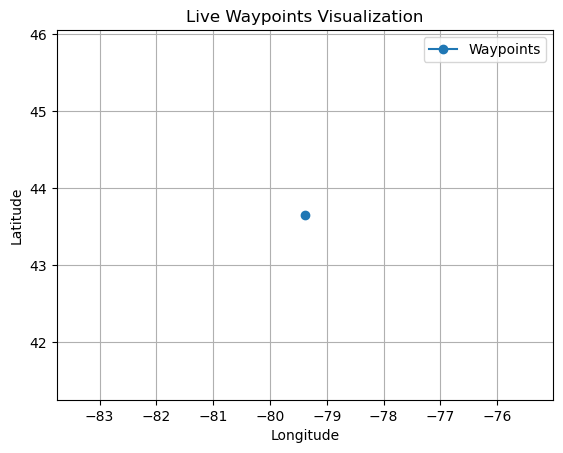

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

KeyboardInterrupt: 

In [4]:


# Live plot the waypoints
import time

plt.ion()  # Turn on interactive mode
fig, ax = plt.subplots()
line, = ax.plot([], [], marker='o', label='Waypoints')  # Initialize the line plot
ax.set_title("Live Waypoints Visualization")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.grid(True)

# Loop through the waypoints to simulate live plotting
for i in range(len(waypoints)):
    # Get the current subset of waypoints
    subset = waypoints[:i+1]
    lats, lons = zip(*subset)  # Separate latitudes and longitudes

    # Update the plot
    line.set_data(lons, lats)
    ax.relim()  # Recalculate the limits of the plot
    ax.autoscale_view()  # Automatically adjust the view
    plt.draw()
    plt.pause(0.2)  # Pause to simulate live updates

# Keep the plot open after the loop
plt.ioff()
plt.show()



In [16]:
from geopy.distance import geodesic
from geopy.point import Point
from math import degrees, atan2

def geopy_bearing(lat1, lon1, lat2, lon2):
    point1 = Point(lat1, lon1)
    point2 = Point(lat2, lon2)
    return geodesic(point1, point2).initial

# Compare:
# bearing_custom = calculate_bearing(lat1, lon1, lat2, lon2)
bearing_geopy = geopy_bearing(lat1, lon1, lat2, lon2)

print(f"Custom Bearing: {bearing_custom}")
print(f"Geopy Bearing: {bearing_geopy}")




AttributeError: 'geodesic' object has no attribute 'initial'

In [2]:
import math

# Replace these values with the quaternion from your pose
qx = -0.003134124280743432
qy = 0.002411491165231385
qz = 0.6535862668088084
qw = 0.7568416966673269

# Calculate yaw (theta) from quaternion
siny_cosp = 2 * (qw * qz + qx * qy)
cosy_cosp = 1 - 2 * (qy**2 + qz**2)
yaw = math.atan2(siny_cosp, cosy_cosp)  # Yaw in radians
yaw_degrees = math.degrees(yaw)  # Convert to degrees

print(f"Yaw (radians): {yaw}")
print(f"Yaw (degrees): {yaw_degrees}")


Yaw (radians): 1.4246337345477036
Yaw (degrees): 81.62550034154428


In [44]:
import pandas as pd

# Load the CSV file and count rows
def count_rows_with_pandas(filepath):
    try:
        data = pd.read_csv(filepath)  # Load the CSV file into a DataFrame
        return len(data)  # Return the number of rows
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return 0
    except Exception as e:
        print(f"Error reading the file: {e}")
        return 0

# Example usage
csv_file_path = '/home/user/abd_ws/zigzag_path_waypoints.csv'  # Replace with your CSV file path
number_of_rows = count_rows_with_pandas(csv_file_path)
print(f"Number of rows in the CSV file: {number_of_rows}")



Number of rows in the CSV file: 130


In [2]:
import csv

# Load waypoints function
def load_waypoints(filepath):
    waypoints = []
    try:
        with open(filepath, 'r') as file:
            reader = csv.reader(file)
            for row_number, row in enumerate(reader, start=1):
                try:
                    lat = float(row[1])
                    lon = float(row[0])
                    waypoints.append((lat, lon))
                except (ValueError, IndexError):
                    print(f"Skipping invalid row {row_number}: {row}")
    except FileNotFoundError:
        print(f"Waypoint file '{filepath}' not found.")
        return []
    return waypoints

# Load and display waypoints
filepath = '/home/user/abd_ws/zigzag_path_waypoints.csv'  # Update with your actual file path
waypoints = load_waypoints(filepath)

# Display waypoints
print("Loaded Waypoints:")
for index, (lat, lon) in enumerate(waypoints, start=1):
    print(f"Waypoint {index}: Latitude = {lat}, Longitude = {lon}")


Skipping invalid row 1: ['longitude', 'latitude']
Loaded Waypoints:
Waypoint 1: Latitude = 43.653201389405, Longitude = -79.38332021422791
Waypoint 2: Latitude = 43.65319151268226, Longitude = -79.38332160865922
Waypoint 3: Latitude = 43.65318193090952, Longitude = -79.38332261831982
Waypoint 4: Latitude = 43.65317269304817, Longitude = -79.38332327436349
Waypoint 5: Latitude = 43.65316384805962, Longitude = -79.38332360794409
Waypoint 6: Latitude = 43.653155444905245, Longitude = -79.38332365021542
Waypoint 7: Latitude = 43.65314753254646, Longitude = -79.38332343233134
Waypoint 8: Latitude = 43.653140159944634, Longitude = -79.3833229854456
Waypoint 9: Latitude = 43.65313337606118, Longitude = -79.38332234071211
Waypoint 10: Latitude = 43.65312722985749, Longitude = -79.38332152928461
Waypoint 11: Latitude = 43.653121770294945, Longitude = -79.383320582317
Waypoint 12: Latitude = 43.65312103534213, Longitude = -79.3833101297283
Waypoint 13: Latitude = 43.65312753615984, Longitude = -

In [3]:
waypoints[100]

(43.65317019258689, -79.3832305145926)

In [10]:
import pyproj

def convert_gps_to_local(base_lat, base_lon, lat, lon):
    """
    Convert GPS coordinates to local Cartesian coordinates using a reference GPS point.

    Args:
        base_lat (float): Latitude of the base reference point.
        base_lon (float): Longitude of the base reference point.
        lat (float): Latitude of the target point.
        lon (float): Longitude of the target point.

    Returns:
        tuple: (distance_x, distance_y) in meters relative to the base point.
    """
    geod = pyproj.Geod(ellps="WGS84")
    
    # Calculate distances in meters
    _, _, distance_x = geod.inv(base_lon, base_lat, lon, base_lat)
    _, _, distance_y = geod.inv(base_lon, base_lat, base_lon, lat)

    # Adjust for signs
    if lon > base_lon:
        distance_x = -distance_x
    if lat < base_lat:
        distance_y = -distance_y

    return distance_x, distance_y


# Example usage:-79.38328890987891, 

base_lat = 43.653199983217306  # Replace with your base latitude
base_lon = -79.38319997008247  # Replace with your base longitude
target_lat = waypoints[129][0]# Replace with your target latitude
target_lon = waypoints[129][1]  # Replace with your target longitude

# Call the function to convert GPS to local coordinates
distance_x, distance_y = convert_gps_to_local(base_lat, base_lon, target_lat, target_lon)

print(f"Base GPS: Lat = {base_lat}, Lon = {base_lon}")
print(f"Target GPS: Lat = {target_lat}, Lon = {target_lon}")
print(f"Local Coordinates: x = {distance_x:.2f} m, y = {distance_y:.2f} m")

Base GPS: Lat = 43.653199983217306, Lon = -79.38319997008247
Target GPS: Lat = 43.65316393280985, Lon = -79.38320021422787
Local Coordinates: x = 0.02 m, y = -4.01 m


In [6]:
waypoints[129][0]

43.65316393280985

In [12]:
import math

# Helper functions
def calculate_distance(x1, y1, x2, y2):
    """
    Calculate the Euclidean distance between two points.
    Args:
        x1 (float): X coordinate of the first point.
        y1 (float): Y coordinate of the first point.
        x2 (float): X coordinate of the second point.
        y2 (float): Y coordinate of the second point.
    Returns:
        float: Distance between the two points.
    """
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

def calculate_angle(x1, y1, x2, y2):
    """
    Calculate the angle to the target point from the current point.
    Args:
        x1 (float): X coordinate of the current point.
        y1 (float): Y coordinate of the current point.
        x2 (float): X coordinate of the target point.
        y2 (float): Y coordinate of the target point.
    Returns:
        float: Angle in radians.
    """
    return math.atan2(y2 - y1, x2 - x1)

# Test example
current_x = 0.0  # Replace with your current X coordinate
current_y = 0.0  # Replace with your current Y coordinate
target_x = distance_x  # Replace with your target X coordinate
target_y = distance_y  # Replace with your target Y coordinate

# Calculate distance and angle
distance = calculate_distance(current_x, current_y, target_x, target_y)
angle_to_target = calculate_angle(current_x, current_y, target_x, target_y)

print(f"Current Position: x = {current_x}, y = {current_y}")
print(f"Target Position: x = {target_x}, y = {target_y}")
print(f"Distance to Target: {distance:.2f} meters")
print(f"Angle to Target: {math.degrees(angle_to_target):.2f} degrees")


Current Position: x = 0.0, y = 0.0
Target Position: x = 0.019695672529961638, y = -4.00539755497808
Distance to Target: 4.01 meters
Angle to Target: -89.72 degrees


In [13]:
max_steering = 1.5  # Maximum steering value
steering_interval = 0.1  # Steering increment

        # Map the alpha angle to a steering value
if math.degrees(angle_to_target) >= 0:  # Right/East side
    normalized_alpha = min(math.degrees(angle_to_target) / 180, 1.0)  # Normalize alpha to [0, 1]
    steering = round(normalized_alpha * max_steering / steering_interval) * steering_interval
else:  # Left/West side
    normalized_alpha = min(math.degrees(-angle_to_target) / 180, 1.0)  # Normalize alpha to [0, 1]
    steering = -round(normalized_alpha * max_steering / steering_interval) * steering_interval

steering

-0.7000000000000001

In [71]:
# angle_to_target = 0.175

normalized_alpha = min(math.degrees(angle_to_target) / 180, 1.0)
normalized_alpha

0.05570423008216336

In [72]:
max_steering = 1.5  # Maximum steering value
steering_interval = 0.1

steering = round(normalized_alpha * max_steering / steering_interval) * steering_interval
steering

0.1

In [73]:
normalized_alpha = min(math.degrees(-angle_to_target) / 180, 1.0)  # Normalize alpha to [0, 1]
steering = -round(normalized_alpha * max_steering / steering_interval) * steering_interval
steering

0.1

In [58]:


import csv
import math

def load_waypoints(filepath):
    waypoints = []
    try:
        with open(filepath, 'r') as file:
            reader = csv.reader(file)
            for row_number, row in enumerate(reader, start=1):
                try:
                    lat = float(row[1])  # Latitude from second column
                    lon = float(row[0])  # Longitude from first column
                    waypoints.append((lat, lon))
                except (ValueError, IndexError):
                    print(f"Skipping invalid row {row_number}: {row}")
    except FileNotFoundError:
        print(f"Waypoint file '{filepath}' not found.")
        exit()
    return waypoints

# Example usage
filepath = '/home/user/abd_ws/zigzag_path_waypoints.csv'  # Update with your actual file path
waypoints = load_waypoints(filepath)

print("Loaded Waypoints:")
for index, (lat, lon) in enumerate(waypoints, start=1):
    print(f"Waypoint {index}: Latitude = {lat}, Longitude = {lon}")


Skipping invalid row 1: ['longitude', 'latitude']
Loaded Waypoints:
Waypoint 1: Latitude = 43.653201389405, Longitude = -79.38332021422791
Waypoint 2: Latitude = 43.65319151268226, Longitude = -79.38332160865922
Waypoint 3: Latitude = 43.65318193090952, Longitude = -79.38332261831982
Waypoint 4: Latitude = 43.65317269304817, Longitude = -79.38332327436349
Waypoint 5: Latitude = 43.65316384805962, Longitude = -79.38332360794409
Waypoint 6: Latitude = 43.653155444905245, Longitude = -79.38332365021542
Waypoint 7: Latitude = 43.65314753254646, Longitude = -79.38332343233134
Waypoint 8: Latitude = 43.653140159944634, Longitude = -79.3833229854456
Waypoint 9: Latitude = 43.65313337606118, Longitude = -79.38332234071211
Waypoint 10: Latitude = 43.65312722985749, Longitude = -79.38332152928461
Waypoint 11: Latitude = 43.653121770294945, Longitude = -79.383320582317
Waypoint 12: Latitude = 43.65312103534213, Longitude = -79.3833101297283
Waypoint 13: Latitude = 43.65312753615984, Longitude = -

In [62]:
waypoints[0]

(43.653201389405, -79.38332021422791)

In [63]:
def convert_gps_to_local(base_lat, base_lon, lat, lon):
    """
    Convert GPS coordinates to local Cartesian coordinates using a reference GPS point.

    Args:
        base_lat (float): Latitude of the base reference point.
        base_lon (float): Longitude of the base reference point.
        lat (float): Latitude of the target point.
        lon (float): Longitude of the target point.

    Returns:
        tuple: (distance_x, distance_y) in meters relative to the base point.
    """
    geod = pyproj.Geod(ellps="WGS84")

    # Calculate distances in meters
    _, _, distance_x = geod.inv(base_lon, base_lat, lon, base_lat)
    _, _, distance_y = geod.inv(base_lon, base_lat, base_lon, lat)

    # Adjust for signs
    if lon > base_lon:
        distance_x = -distance_x
    if lat < base_lat:
        distance_y = -distance_y

    return distance_x, distance_y

if waypoints:
    base_lat, base_lon = 43.653199983217306 , -79.38319997008247   # Use the first waypoint as the base reference
    target_lat, target_lon = waypoints[1]  # Use the second waypoint as the target point

    distance_x, distance_y = convert_gps_to_local(base_lat, base_lon, target_lat, target_lon)
    print(f"Base GPS: Lat = {base_lat}, Lon = {base_lon}")
    print(f"Target GPS: Lat = {target_lat}, Lon = {target_lon}")
    print(f"Local Coordinates: x = {distance_x:.2f} m, y = {distance_y:.2f} m")


Base GPS: Lat = 43.653199983217306, Lon = -79.38319997008247
Target GPS: Lat = 43.65319151268226, Lon = -79.38332160865922
Local Coordinates: x = 9.81 m, y = -0.94 m
